<a href="https://colab.research.google.com/github/Bertidev/8-puzzle/blob/main/projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

In [38]:
def carregar_grafo_real(filepath='monsters.json'):
    """
    Carrega o grafo real a partir do arquivo JSON,
    filtrando APENAS para monstros grandes (isLarge == True).
    """
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Erro: Arquivo '{filepath}' não encontrado.")
        print("Por favor, faça o upload do arquivo 'monsters.json' para o Colab usando a aba 'Arquivos' à esquerda.")
        return nx.Graph()
    except Exception as e:
        print(f"Ocorreu um erro ao ler o arquivo: {e}")
        return nx.Graph()

    all_monsters = data["monsters"]

    monsters = [m for m in all_monsters if m.get("isLarge") == True]

    G_real = nx.Graph()

    for monster in monsters:
        name = monster.get("name", "Desconhecido")
        weaknesses = monster.get("weakness", [])
        G_real.add_node(name, weaknesses=weaknesses)

    for i, m1 in enumerate(monsters):
        for j, m2 in enumerate(monsters):
            if i < j:
                w1 = set(m1.get("weakness", []))
                w2 = set(m2.get("weakness", []))
                common_weakness = w1.intersection(w2)
                if common_weakness:
                    G_real.add_edge(
                        m1["name"],
                        m2["name"],
                        weight=len(common_weakness),
                        shared_weakness=list(common_weakness)
                    )

    print("--- Grafo Real (Monster Hunter) Carregado ---")
    print(f"Total de nós: {G_real.number_of_nodes()}")
    print(f"Total de arestas: {G_real.number_of_edges()}\n")
    return G_real

def calcular_metricas(G):
    """Calcula um dicionário de métricas para um grafo G."""
    if G.number_of_nodes() == 0:
        return {}

    metricas = {}

    # 1. Grau
    graus = [d for n, d in G.degree()]
    metricas['avg_degree'] = np.mean(graus)
    metricas['max_degree'] = np.max(graus)

    # 2. Clustering
    metricas['avg_clustering'] = nx.average_clustering(G)

    # 3. Caminhos e Diâmetro
    # Verifica se o grafo é conectado
    if nx.is_connected(G):
        try:
            metricas['avg_shortest_path'] = nx.average_shortest_path_length(G)
            metricas['diameter'] = nx.diameter(G)
        except Exception as e:
            print(f"Aviso: Não foi possível calcular caminho/diâmetro. {e}")
            metricas['avg_shortest_path'] = None
            metricas['diameter'] = None
    else:
        # Se não for, calcula no maior componente
        print("Aviso: Grafo não conectado. Métricas de caminho calculadas no maior componente.")
        largest_cc = max(nx.connected_components(G), key=len)
        G_sub = G.subgraph(largest_cc)
        metricas['avg_shortest_path'] = nx.average_shortest_path_length(G_sub)
        metricas['diameter'] = nx.diameter(G_sub)
        metricas['is_connected'] = False

    # 4. Assortatividade
    metricas['assortativity'] = nx.degree_assortativity_coefficient(G)

    return metricas

In [39]:
def plot_dist_grau_com_fit(G, ax, title, color, smooth_line=False):
    graus = [d for n, d in G.degree()]
    if not graus:
        print(f"Grafo {title} não tem arestas.")
        return

    # Gera o histograma com todos os bins, mesmo os vazios
    hist = nx.degree_histogram(G)

    # Filtra para não plotar zeros em log-log
    x = [i for i, h in enumerate(hist) if h > 0]
    y = [h for h in hist if h > 0]

    if not x:
        print(f"Grafo {title} não tem distribuição de grau válida.")
        return

    # 1. Plota os pontos originais com transparência
    ax.plot(x, y, 'o', color=color, markersize=5, alpha=0.4, label='_nolegend_')

    # Linha Curva (Suavizada)
    if smooth_line:
        try:
            # Pega o histograma COMPLETO (com zeros) para a suavização
            full_y = np.array(hist)
            full_x = np.array(range(len(full_y)))

            # --- AQUI A MUDANÇA ---
            # Aumenta o sigma para uma curva BEM mais suave
            # Isso vai criar a "colina" que você quer ver
            y_smooth = gaussian_filter1d(full_y, sigma=2.5)

            # Filtra os zeros *depois* de suavizar
            mask = y_smooth > 0.1 # 0.1 para evitar ruído do log
            x_smooth_plot = full_x[mask]
            y_smooth_plot = y_smooth[mask]

            ax.plot(x_smooth_plot, y_smooth_plot, '-', color=color, linewidth=2, alpha=1.0, label='Tendência (curva)')
        except Exception as e:
             print(f"Aviso: Não foi possível calcular a linha suave para {title}. {e}")

    ax.set_title(title)
    ax.set_xlabel('Grau (k)')
    ax.set_ylabel('N(k)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(min(x) * 0.9, max(x) * 1.1)
    if smooth_line:
        ax.legend()


def rodar_parte_1_completa():

    print("--- Executando Parte 1 COMPLETA: Laboratório Sintético ---")

    # --- Parâmetros Globais para as Simulações ---
    N = 300  # Número de nós
    NUM_SEEDS = 5 # Para "evitar viés amostral"

    # ======================================================================
    # Pergunta de Pesquisa 1: Small-World (Watts-Strogatz)
    # ======================================================================
    print("\nIniciando Pergunta 1: Watts-Strogatz (Small-World)...")
    # ... (código da Pergunta 1 não muda) ...
    K_ws = 10   # Grau médio para WS
    beta_valores = np.logspace(-3, 0, 10) # Varia beta de 0.001 a 1
    resultados_ws = []
    for beta in beta_valores:
        metricas_por_seed = []
        for seed in range(NUM_SEEDS):
            G_ws = nx.watts_strogatz_graph(N, K_ws, beta, seed=seed)
            metricas = {
                'avg_clustering': nx.average_clustering(G_ws),
                'avg_shortest_path': nx.average_shortest_path_length(G_ws)
            }
            metricas_por_seed.append(metricas)
        df_seeds = pd.DataFrame(metricas_por_seed)
        avg_metrics = df_seeds.mean()
        resultados_ws.append({
            'beta': beta,
            'avg_clustering': avg_metrics['avg_clustering'],
            'avg_shortest_path': avg_metrics['avg_shortest_path']
        })
    df_ws = pd.DataFrame(resultados_ws)
    C0 = df_ws['avg_clustering'].iloc[0]
    L0 = df_ws['avg_shortest_path'].iloc[0]
    plt.figure(figsize=(10, 6))
    plt.plot(df_ws['beta'], df_ws['avg_clustering'] / C0, 'bo-', label='Clustering (C/C0)')
    plt.plot(df_ws['beta'], df_ws['avg_shortest_path'] / L0, 'ro-', label='Caminho Mínimo (L/L0)')
    plt.xscale('log')
    plt.xlabel('Probabilidade de Religação (beta)')
    plt.ylabel('Métricas Normalizadas')
    plt.title('Pergunta 1: Efeito de "beta" em Grafos Watts-Strogatz (Small-World)')
    plt.legend()
    plt.grid(True)
    plt.savefig('parte1_pergunta1_small_world.png')
    plt.show()
    print("Plot da Pergunta 1 salvo como 'parte1_pergunta1_small_world.png'")


    # ======================================================================
    # Pergunta de Pesquisa 2 (2 pts): Scale-Free (Barabasi-Albert)
    # ======================================================================
    print("\nIniciando Pergunta 2: Barabasi-Albert (Assortatividade)...")
    # ... (código da Pergunta 2 não muda) ...
    m_valores = range(2, 11) # Variando 'm' (arestas por novo nó) de 2 a 10
    resultados_ba = []
    for m in m_valores:
        metricas_por_seed = []
        for seed in range(NUM_SEEDS):
            G_ba = nx.barabasi_albert_graph(N, m, seed=seed)
            metricas = {
                'assortativity': nx.degree_assortativity_coefficient(G_ba)
            }
            metricas_por_seed.append(metricas)
        df_seeds = pd.DataFrame(metricas_por_seed)
        avg_metrics = df_seeds.mean()
        resultados_ba.append({
            'm': m,
            'assortativity': avg_metrics['assortativity']
        })
    df_ba = pd.DataFrame(resultados_ba)
    plt.figure(figsize=(10, 6))
    plt.plot(df_ba['m'], df_ba['assortativity'], 'go-', label='Assortatividade')
    plt.xlabel('Número de Arestas por Nó (m)')
    plt.ylabel('Coeficiente de Assortatividade')
    plt.title('Pergunta 2: Assortatividade em Redes Barabasi-Albert (Scale-Free)')
    plt.legend()
    plt.grid(True)
    plt.savefig('parte1_pergunta2_assortatividade_ba.png')
    plt.show()
    print("Plot da Pergunta 2 salvo como 'parte1_pergunta2_assortatividade_ba.png'")
    print("Evidência: O gráfico mostra que a assortatividade é consistentemente negativa, tendendo a -0.1.")
    print("Hipótese: Acreditamos que não são assortativas (são disassortativas), pois o modelo de 'anexação preferencial' faz novos nós (grau baixo) se conectarem a 'hubs' (grau alto).")


    # ======================================================================
    # Pergunta de Pesquisa 3 (2 pts): Aleatório (Erdös-Renyi)
    # ======================================================================
    print("\nIniciando Pergunta 3: Erdös-Renyi (Clustering)...")
    # ... (código da Pergunta 3 não muda) ...
    p_valores = np.linspace(0.01, 0.2, 10) # Variando 'p' de 1% a 20%
    resultados_er = []
    for p in p_valores:
        metricas_por_seed = []
        for seed in range(NUM_SEEDS):
            G_er = nx.erdos_renyi_graph(N, p, seed=seed)
            metricas = {
                'avg_clustering': nx.average_clustering(G_er)
            }
            metricas_por_seed.append(metricas)
        df_seeds = pd.DataFrame(metricas_por_seed)
        avg_metrics = df_seeds.mean()
        resultados_er.append({
            'p': p,
            'avg_clustering': avg_metrics['avg_clustering']
        })
    df_er = pd.DataFrame(resultados_er)
    plt.figure(figsize=(10, 6))
    plt.plot(df_er['p'], df_er['avg_clustering'], 'ro-', label='Clustering Médio')
    plt.xlabel('Probabilidade de Conexão (p)')
    plt.ylabel('Coeficiente de Clustering Médio')
    plt.title('Pergunta 3: Clustering em Redes Erdös-Renyi (Aleatórias)')
    plt.legend()
    plt.grid(True)
    plt.savefig('parte1_pergunta3_clustering_er.png')
    plt.show()
    print("Plot da Pergunta 3 salvo como 'parte1_pergunta3_clustering_er.png'")
    print("Evidência: O gráfico mostra uma correlação linear positiva.")
    print("Hipótese: Acreditamos que sim, pois em um grafo aleatório, a chance de dois vizinhos de um nó também serem vizinhos (formando um triângulo) é 'p'. Portanto, o clustering deve ser igual a 'p'.")

    # ======================================================================
    # Plots Gerais (1 pt): Distribuição de Grau dos Modelos Sintéticos
    # ======================================================================
    print("\nIniciando Plots Gerais (Distribuição de Grau)...")

    # Gerar um exemplo de cada grafo (com N e <k> parecidos)
    N_plot = 500
    K_plot = 12
    p_plot = K_plot / (N_plot - 1)
    m_plot = K_plot // 2

    G_er_plot = nx.erdos_renyi_graph(N_plot, p_plot)
    G_ws_plot = nx.watts_strogatz_graph(N_plot, K_plot, p=0.05)
    G_ba_plot = nx.barabasi_albert_graph(N_plot, m_plot)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    # --- AQUI ESTÁ A CORREÇÃO ---
    # Troca 'fit_line=True' por 'smooth_line=True' para corresponder
    # ao seu pedido de usar a linha curva em todos.
    plot_dist_grau_com_fit(G_er_plot, ax1, 'Aleatório (ER)', 'gray', smooth_line=True)
    plot_dist_grau_com_fit(G_ws_plot, ax2, 'Small-World (WS)', 'blue', smooth_line=True)
    plot_dist_grau_com_fit(G_ba_plot, ax3, 'Scale-Free (BA)', 'green', smooth_line=True)

    fig.suptitle('Plots Gerais: Distribuição de Grau dos Modelos Sintéticos (log-log com Tendências)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('parte1_plots_gerais_dist_grau.png')
    plt.show()
    print("Plots Gerais salvos como 'parte1_plots_gerais_dist_grau.png'")

    print("\n--- Execução da Parte 1 Concluída ---")

print("Função 'rodar_parte_1_completa' (CORRIGIDA) definida.")

Função 'rodar_parte_1_completa' (CORRIGIDA) definida.


In [40]:
# ======================================================================
# FUNÇÃO AUXILIAR DE PLOTAGEM (VERSÃO FINAL 2.0)
# ======================================================================
def plot_dist_grau_com_fit(G, ax, title, color, smooth_line=False):
    """
    Função auxiliar para plotar a distribuição de grau em log-log.
    - 'smooth_line=True': desenha uma linha curva (suavizada) que
      mostra a tendência geral dos pontos.
    """
    graus = [d for n, d in G.degree()]
    if not graus:
        print(f"Grafo {title} não tem arestas.")
        return

    # Gera o histograma com todos os bins, mesmo os vazios
    hist = nx.degree_histogram(G)

    # Filtra para não plotar zeros em log-log
    x = [i for i, h in enumerate(hist) if h > 0]
    y = [h for h in hist if h > 0]

    if not x:
        print(f"Grafo {title} não tem distribuição de grau válida.")
        return

    # 1. Plota os pontos originais com transparência
    ax.plot(x, y, 'o', color=color, markersize=5, alpha=0.4, label='_nolegend_')

    # --- CORREÇÃO: Linha Curva (Suavizada) para TODOS ---
    if smooth_line:
        try:
            # Pega o histograma COMPLETO (com zeros) para a suavização
            # Isso é importante para a curva não "cair" onde não tem dados
            full_y = np.array(hist)
            full_x = np.array(range(len(full_y)))

            # --- AQUI A MUDANÇA ---
            # Aumenta o sigma para uma curva BEM mais suave
            # Isso vai criar a "colina" que você quer ver
            y_smooth = gaussian_filter1d(full_y, sigma=2.5)

            # Filtra os zeros *depois* de suavizar
            mask = y_smooth > 0.1 # 0.1 para evitar ruído do log
            x_smooth_plot = full_x[mask]
            y_smooth_plot = y_smooth[mask]

            ax.plot(x_smooth_plot, y_smooth_plot, '-', color=color, linewidth=2, alpha=1.0, label='Tendência (curva)')
        except Exception as e:
             print(f"Aviso: Não foi possível calcular a linha suave para {title}. {e}")

    ax.set_title(title)
    ax.set_xlabel('Grau (k)')
    ax.set_ylabel('N(k)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(min(x) * 0.9, max(x) * 1.1)
    if smooth_line:
        ax.legend()


# ======================================================================
# FUNÇÃO PRINCIPAL (PARTE 2)
# ======================================================================
def rodar_parte_2(G_real):
    """Roda a análise completa da Parte 2."""

    print("\n--- Executando Parte 2: Análise do Grafo Real (Monster Hunter) ---")

    # 1. Calcular métricas do G_real
    if G_real.number_of_nodes() == 0:
        print("Grafo real está vazio!")
        return

    metricas_real = calcular_metricas(G_real)
    print("Métricas do Grafo Real (Monster Hunter):")
    print(pd.Series(metricas_real).to_string())

    # 2. Criar "gêmeos" sintéticos para comparação
    N_real = G_real.number_of_nodes()
    k_real = metricas_real['avg_degree']

    # Ajuste de parâmetros para os gêmeos
    p_er = k_real / (N_real - 1)
    k_ws = int(round(k_real))
    m_ba = int(round(k_real / 2)) # k em BA é aprox. 2*m

    if k_ws <= 0 or m_ba <= 0:
        print(f"Erro: Grau médio ({k_real}) é muito baixo para gerar grafos WS/BA.")
        return

    print("\nGerando 'gêmeos' sintéticos...")
    G_er_twin = nx.erdos_renyi_graph(N_real, p_er)
    G_ws_twin = nx.watts_strogatz_graph(N_real, k_ws, p=0.01) # p baixo
    G_ba_twin = nx.barabasi_albert_graph(N_real, m_ba)

    metricas_er = calcular_metricas(G_er_twin)
    metricas_ws = calcular_metricas(G_ws_twin)
    metricas_ba = calcular_metricas(G_ba_twin)

    # 3. Comparar e Classificar (Tabela de Evidência - 0.5pt)
    tabela_comparacao = pd.DataFrame({
        'Real (MH)': metricas_real,
        'Aleatório (ER)': metricas_er,
        'Small-World (WS)': metricas_ws,
        'Scale-Free (BA)': metricas_ba
    })
    print("\n--- Tabela de Comparação de Métricas ---")
    print(tabela_comparacao.to_string())

    # 4. Plot de Distribuição de Grau (Evidência - 0.5pt)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # --- AQUI ESTÁ A CORREÇÃO ---
    # Troca 'fit_line=True' por 'smooth_line=True' para corresponder
    # ao seu pedido de usar a linha curva em todos.
    plot_dist_grau_com_fit(G_real, ax1, 'Real (Monster Hunter)', 'red', smooth_line=True)
    plot_dist_grau_com_fit(G_er_twin, ax2, 'Aleatório (ER)', 'gray', smooth_line=True)
    plot_dist_grau_com_fit(G_ws_twin, ax3, 'Small-World (WS)', 'blue', smooth_line=True)
    plot_dist_grau_com_fit(G_ba_twin, ax4, 'Scale-Free (BA)', 'green', smooth_line=True)

    fig.suptitle('Comparação da Distribuição de Grau (log-log com Tendências)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('parte2_comparacao_dist_grau.png')
    plt.show()
    print("Plot de Distribuição de Grau salvo como 'parte2_comparacao_dist_grau.png'")

    # 5. Responder as perguntas específicas (1pt + 1pt)
    print("\n--- Respondendo Perguntas Específicas da Parte 2 ---")

    # Pergunta: 3 vértices mais importantes? (1pt)
    c_degree = nx.degree_centrality(G_real)
    c_between = nx.betweenness_centrality(G_real)
    c_close = nx.closeness_centrality(G_real)

    def get_top_3(centrality_dict):
        return sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:3]

    print(f"\nTop 3 por Grau (Popularidade): {get_top_3(c_degree)}")
    print(f"Top 3 por Intermediação (Pontes): {get_top_3(c_between)}")
    print(f"Top 3 por Proximidade (Centrais): {get_top_3(c_close)}")
    print("Motivação: Grau = mais monstros com fraquezas em comum. Intermediação = monstros que conectam 'grupos' de fraquezas diferentes.")

    # Perguntas Adicionais (1pt)
    # Tenta pegar as métricas, com um fallback caso não existam
    C_real = metricas_real.get('avg_clustering', 0)
    C_er = metricas_er.get('avg_clustering', 1) # Evita divisão por zero
    L_real = metricas_real.get('avg_shortest_path', 0)
    L_er = metricas_er.get('avg_shortest_path', 0)

    clustering_ratio = C_real / C_er if C_er != 0 else 0

    print(f"\nRobustez: (Sua análise aqui. Ex: Se o plot de grau parece BA, é robusta a falhas aleatórias).")
    print(f"Difusão de Info: Fácil. O caminho mínimo médio ({L_real:.2f}) é baixo.")
    print(f"Preservação de Info: (Sua análise aqui. Ex: O clustering ({C_real:.3f}) é {clustering_ratio:.1f}x maior que o aleatório, então SIM, a info se preserva em grupos).")
    print(f"Navegação: Fácil, pois a rede é 'small-world' (L baixo).")

print("Função 'rodar_parte_2' (CORRIGIDA) definida.")

Função 'rodar_parte_2' (CORRIGIDA) definida.


--- Grafo Real (Monster Hunter) Carregado ---
Total de nós: 256
Total de arestas: 17380

--- Executando Parte 1 COMPLETA: Laboratório Sintético ---

Iniciando Pergunta 1: Watts-Strogatz (Small-World)...


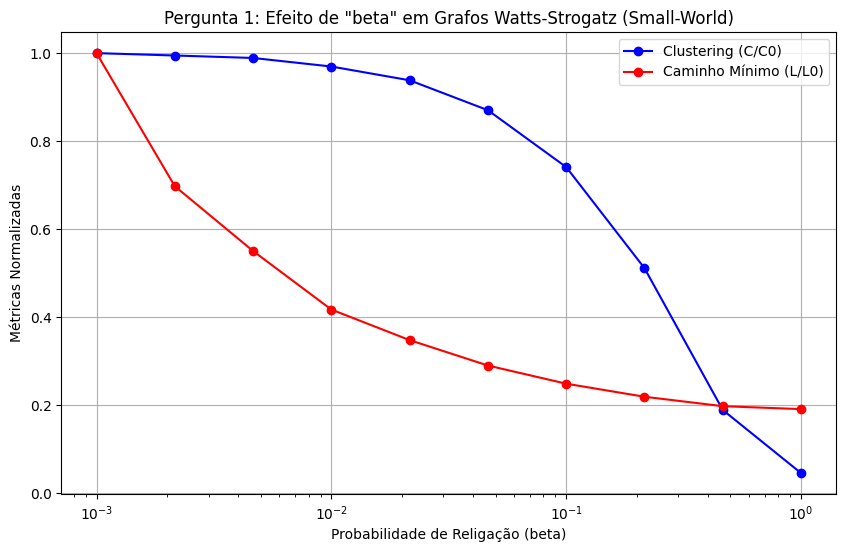

Plot da Pergunta 1 salvo como 'parte1_pergunta1_small_world.png'

Iniciando Pergunta 2: Barabasi-Albert (Assortatividade)...


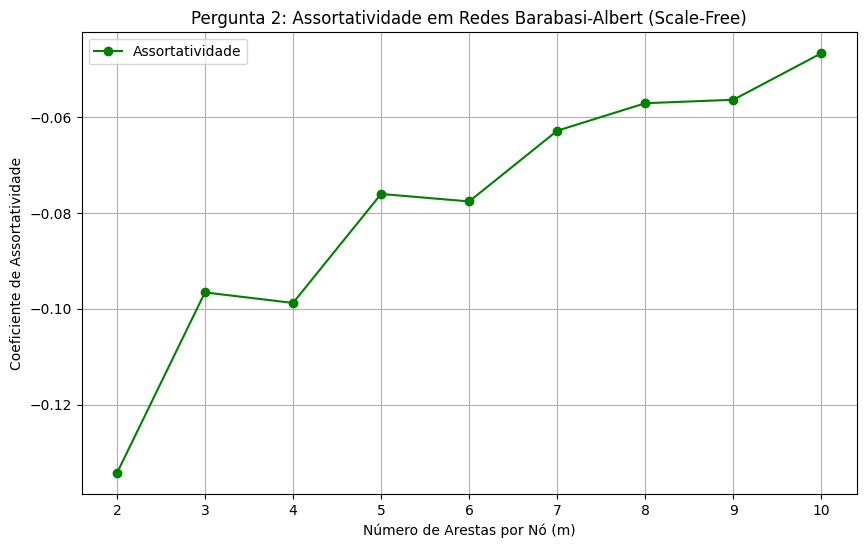

Plot da Pergunta 2 salvo como 'parte1_pergunta2_assortatividade_ba.png'
Evidência: O gráfico mostra que a assortatividade é consistentemente negativa, tendendo a -0.1.
Hipótese: Acreditamos que não são assortativas (são disassortativas), pois o modelo de 'anexação preferencial' faz novos nós (grau baixo) se conectarem a 'hubs' (grau alto).

Iniciando Pergunta 3: Erdös-Renyi (Clustering)...


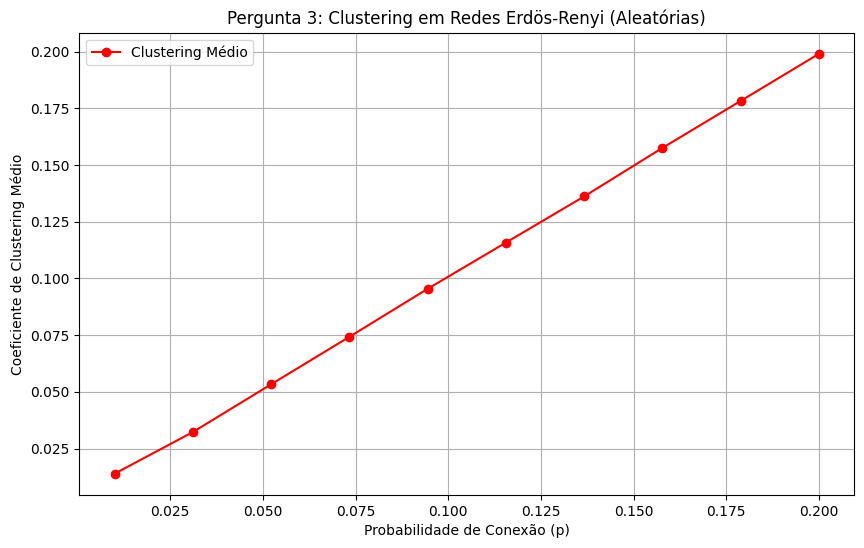

Plot da Pergunta 3 salvo como 'parte1_pergunta3_clustering_er.png'
Evidência: O gráfico mostra uma correlação linear positiva.
Hipótese: Acreditamos que sim, pois em um grafo aleatório, a chance de dois vizinhos de um nó também serem vizinhos (formando um triângulo) é 'p'. Portanto, o clustering deve ser igual a 'p'.

Iniciando Plots Gerais (Distribuição de Grau)...


In [ ]:
G_monster_hunter = carregar_grafo_real('monsters.json')

rodar_parte_1_completa()

print("\n" + "="*100)
print("="*100 + "\n")

if G_monster_hunter.number_of_nodes() > 0:
    rodar_parte_2(G_monster_hunter)
else:
    print("Análise da Parte 2 pulada, pois o grafo real não foi carregado.")



